## How was data collected (text from 1st milestone):

## Data Cleaning

In [1]:
#install.packages("tidyverse")
library(tidyverse)


── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
cars_raw = read_csv("serbia_car_sales_price_2024.csv")

Rows: 8413 Columns: 18
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (11): post_info, car_name, A/C, emission_class, horsepower, color, type_...
dbl  (7): views, favorite, price, year, seats_amount, car_mileage, km, engin...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
head(cars_raw)

views,favorite,post_info,price,car_name,year,A/C,emission_class,seats_amount,horsepower,color,"car_mileage, km","engine_capacity, cc",type_of_drive,doors,fuel,car_type,gearbox
<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
58,0,posted a week ago,1100,Alfa Romeo 11.9,2002,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
55,0,posted 2 days ago,1100,Alfa Romeo 145,2000,manual A/C,Euro 3,5,106 HP (78 kW),gray,158546,1400,front,2/3 doors,petrol + gas,hatchback,"manual, 5 speeds"
136,4,posted 2 weeks ago,950,Alfa Romeo 145,1999,manual A/C,Euro 3,5,105 HP (77 kW),green,337000,1910,front,2/3 doors,diesel,hatchback,"manual, 5 speeds"
209,1,posted 4 weeks ago,500,Alfa Romeo 146,2000,manual A/C,Euro 3,5,120 HP (88 kW),gray,200000,1600,front,4/5 doors,petrol + gas,limousine,"manual, 5 speeds"
61,0,posted 2 days ago,111,Alfa Romeo 147,2024,automatic A/C,NA,5,116 HP (85 kW),gray,280000,1900,front,2/3 doors,diesel,hatchback,"manual, 5 speeds"
196,2,posted 4 weeks ago,2300,Alfa Romeo 147,2008,no A/C,NA,5,105 HP (77 kW),black,188000,1600,front,4/5 doors,petrol + gas,hatchback,"manual, 5 speeds"


In [4]:
str(cars_raw)

spc_tbl_ [8,413 × 18] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ views              : num [1:8413] 58 55 136 209 61 ...
 $ favorite           : num [1:8413] 0 0 4 1 0 2 1 6 16 0 ...
 $ post_info          : chr [1:8413] "posted a week ago" "posted 2 days ago" "posted 2 weeks ago" "posted 4 weeks ago" ...
 $ price              : num [1:8413] 1100 1100 950 500 111 2300 3500 2150 1350 2000 ...
 $ car_name           : chr [1:8413] "Alfa Romeo 11.9" "Alfa Romeo 145" "Alfa Romeo 145" "Alfa Romeo 146" ...
 $ year               : num [1:8413] 2002 2000 1999 2000 2024 ...
 $ A/C                : chr [1:8413] NA "manual A/C" "manual A/C" "manual A/C" ...
 $ emission_class     : chr [1:8413] NA "Euro 3" "Euro 3" "Euro 3" ...
 $ seats_amount       : num [1:8413] NA 5 5 5 5 5 5 5 5 5 ...
 $ horsepower         : chr [1:8413] NA "106 HP (78 kW)" "105 HP (77 kW)" "120 HP (88 kW)" ...
 $ color              : chr [1:8413] NA "gray" "green" "gray" ...
 $ car_mileage, km    : num [1:8413] NA 158546 337000 

In [5]:
summary(cars_raw)

     views            favorite        post_info             price      
 Min.   :    0.0   Min.   :  0.000   Length:8413        Min.   :  100  
 1st Qu.:   61.0   1st Qu.:  0.000   Class :character   1st Qu.: 1600  
 Median :  114.0   Median :  1.000   Mode  :character   Median : 3300  
 Mean   :  308.7   Mean   :  2.672                      Mean   : 4848  
 3rd Qu.:  245.0   3rd Qu.:  3.000                      3rd Qu.: 5950  
 Max.   :27770.0   Max.   :151.000                      Max.   :82000  
                                                                       
   car_name              year          A/C            emission_class    
 Length:8413        Min.   :1960   Length:8413        Length:8413       
 Class :character   1st Qu.:2003   Class :character   Class :character  
 Mode  :character   Median :2006   Mode  :character   Mode  :character  
                    Mean   :2006                                        
                    3rd Qu.:2010                           

In [6]:
problems(cars_raw)

row,col,expected,actual,file
<int>,<int>,<chr>,<chr>,<chr>


#### Renaming columns for better readability

In [7]:
cars_raw <- cars_raw %>%
rename(post_date=post_info, price_eur=price, ac=`A/C`, mileage_km=`car_mileage, km`, engine_capacity_cc=`engine_capacity, cc`)

#### Casting columns to integer and adding an ID column

In [8]:
cars_raw <- cars_raw %>%
mutate(across(c(views, favorite, price_eur, year, seats_amount, mileage_km, engine_capacity_cc), as.integer)) %>%
mutate(id = row_number()) %>%
relocate(id, .before = 1)

Warning message:
"There was 1 warning in `mutate()`.
ℹ In argument: `across(...)`.
Caused by warning:
! NAs introduced by coercion to integer range"


#### Cleaning and formatting post_date column

In [9]:
cars_raw <- cars_raw %>%
mutate(post_date = str_remove(post_date, "^(posted|updated)\\s?"))

In [10]:
sum(is.na(cars_raw$post_date))

cars_raw %>%
distinct(post_date)

[1] 0

post_date
<chr>
a week ago
2 days ago
2 weeks ago
4 weeks ago
5 days ago
6 days ago
3 weeks ago
yesterday
3 days ago


#### Cleaning ac, emission, horsepower and doors column

In [11]:
sum(is.na(cars_raw$ac))

cars_raw %>%
distinct(ac)

[1] 10

ac
<chr>
NA
manual A/C
automatic A/C
no A/C


In [12]:
cars_raw <- cars_raw %>%
mutate(ac = str_trim(str_remove(ac, "A/C$"))) %>%
mutate(emission_class = str_remove(emission_class, "^Euro\\s?")) %>%
mutate(emission_class = as.integer(emission_class)) %>%
mutate(horsepower = str_extract(horsepower, "^[0-9]+") %>% as.numeric()) %>%
mutate(horsepower = as.integer(horsepower)) %>%
mutate(doors = str_trim(str_remove(doors, "doors$")))

In [13]:
cars_raw %>%
count(color, sort = TRUE)

# Color names are OK

color,n
<chr>,<int>
gray,2628
black,1699
white,1068
blue,889
red,582
teget,364
silver,312
green,275
brown,113


#### Splitting gearbox column into type and speeds

In [14]:
cars_raw %>%
count(gearbox, sort = TRUE)

gearbox,n
<chr>,<int>
"manual, 5 speeds",4645
"manual, 6 speeds",2323
automatic,1164
"manual, 4 speeds",168
semi-automatic,85
"manual, multiple speeds",18
NA,10


In [15]:
cars_raw <- cars_raw %>%
  mutate(
    # Splitting on comma (if there's none, the 'speeds_raw' will be NA)
    speeds_raw = str_split_i(gearbox, ", ", 2),
    gearbox = str_split_i(gearbox, ", ", 1),
    
    
    # Extracting number from speeds_raw, if there's none it will be 0
    speeds = str_extract(speeds_raw, "[0-9]+") %>% as.numeric(),
    speeds = ifelse(is.na(speeds), 0, speeds)
  ) %>%
  select(-speeds_raw) %>%
  mutate(speeds = as.integer(speeds))

#### Transforming car_name into brand and model columns

In [16]:
brands <- c("Alfa Romeo", "Audi", "BMW", "Chevrolet", "Chrysler", "Citroen", 
           "Dacia", "Daewoo", "Daihatsu", "Dodge", "Fiat", "Ford", "Honda", 
           "Hyundai", "Isuzu", "Iveco", "Jaguar", "Jeep", "Kia", "Lada", 
           "Lancia", "Land Rover", "Lexus", "Maserati", "Mazda", "Mercedes", 
           "MG", "Mini", "Mitsubishi", "Moskwitch", "Nissan", "Opel", 
           "Peugeot", "Pontiac", "Porsche", "Renault", "Rover", "Saab", 
           "Seat", "Skoda", "Smart", "SsangYong", "Subaru", "Suzuki", 
           "Tesla", "Toyota", "Trabant", "UAZ", "Volkswagen", "Volvo", 
           "VW", "Wartburg", "Zastava")

# Creating regex
brand_regex <- paste0("^(", paste(sort(brands, decreasing = TRUE), collapse = "|"), ")")

cars_raw <- cars_raw %>%
  mutate(
    brand = str_extract(car_name, brand_regex),
    model = str_remove(car_name, brand_regex) %>% str_trim()
  ) %>%
  select(-car_name) %>% 
  relocate(brand, model, .after = 3)

In [17]:
cars_raw %>%
count(brand, sort = TRUE)

brand,n
<chr>,<int>
Volkswagen,1229
Opel,822
Audi,664
Renault,643
Fiat,619
Peugeot,578
BMW,515
Mercedes,443
Ford,441


In [18]:
cars_raw <- cars_raw %>%
mutate(brand = str_replace(brand, "^VW$", "Volkswagen"))

#### Transforming post_date into days_passed column

In [19]:
cars_raw <- cars_raw %>%
  mutate(post_date = case_when(
    str_detect(post_date, "today")      ~ 0L,
    str_detect(post_date, "yesterday")  ~ 1L,
    str_detect(post_date, "2 days")     ~ 2L,
    str_detect(post_date, "3 days")     ~ 3L,
    str_detect(post_date, "4 days")     ~ 4L,
    str_detect(post_date, "5 days")     ~ 5L,
    str_detect(post_date, "6 days")     ~ 6L,
    str_detect(post_date, "a week ago") ~ 7L,
    str_detect(post_date, "2 weeks")    ~ 14L,
    str_detect(post_date, "3 weeks")    ~ 21L,
    str_detect(post_date, "4 weeks")    ~ 28L,
    str_detect(post_date, "month")      ~ 30L,
    TRUE ~ NA_integer_
  )) %>%
rename(days_passed=post_date)

In [20]:
str(cars_raw)

tibble [8,413 × 21] (S3: tbl_df/tbl/data.frame)
 $ id                : int [1:8413] 1 2 3 4 5 6 7 8 9 10 ...
 $ views             : int [1:8413] 58 55 136 209 61 196 133 290 2629 89 ...
 $ favorite          : int [1:8413] 0 0 4 1 0 2 1 6 16 0 ...
 $ brand             : chr [1:8413] "Alfa Romeo" "Alfa Romeo" "Alfa Romeo" "Alfa Romeo" ...
 $ model             : chr [1:8413] "11.9" "145" "145" "146" ...
 $ days_passed       : int [1:8413] 7 2 14 28 2 28 5 6 7 7 ...
 $ price_eur         : int [1:8413] 1100 1100 950 500 111 2300 3500 2150 1350 2000 ...
 $ year              : int [1:8413] 2002 2000 1999 2000 2024 2008 2008 2008 2008 2007 ...
 $ ac                : chr [1:8413] NA "manual" "manual" "manual" ...
 $ emission_class    : int [1:8413] NA 3 3 3 NA NA 4 4 4 4 ...
 $ seats_amount      : int [1:8413] NA 5 5 5 5 5 5 5 5 5 ...
 $ horsepower        : int [1:8413] NA 106 105 120 116 105 170 90 120 105 ...
 $ color             : chr [1:8413] NA "gray" "green" "gray" ...
 $ mileage_km      

In [21]:
summary(cars_raw)

       id           views            favorite          brand          
 Min.   :   1   Min.   :    0.0   Min.   :  0.000   Length:8413       
 1st Qu.:2104   1st Qu.:   61.0   1st Qu.:  0.000   Class :character  
 Median :4207   Median :  114.0   Median :  1.000   Mode  :character  
 Mean   :4207   Mean   :  308.7   Mean   :  2.672                     
 3rd Qu.:6310   3rd Qu.:  245.0   3rd Qu.:  3.000                     
 Max.   :8413   Max.   :27770.0   Max.   :151.000                     
                                                                      
    model            days_passed      price_eur          year     
 Length:8413        Min.   : 0.00   Min.   :  100   Min.   :1960  
 Class :character   1st Qu.: 4.00   1st Qu.: 1600   1st Qu.:2003  
 Mode  :character   Median : 7.00   Median : 3300   Median :2006  
                    Mean   : 9.64   Mean   : 4848   Mean   :2006  
                    3rd Qu.:14.00   3rd Qu.: 5950   3rd Qu.:2010  
                    Max.   :30

#### Checking the values of every column (missing values, outliers etc.)

In [22]:
cars_raw %>%
filter(views < favorite)

id,views,favorite,brand,model,days_passed,price_eur,year,ac,emission_class,⋯,horsepower,color,mileage_km,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds
<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,⋯,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
680,0,1,Audi,A6,0,3000,2004,automatic,3,⋯,150,red,222000,1790,front,4/5,petrol + gas,caravan,manual,5
727,0,1,Audi,A8,0,4450,2005,automatic,3,⋯,237,black,340000,3000,4x4,4/5,diesel,limousine,automatic,0
4952,0,1,Opel,Zafira,0,650,2004,manual,3,⋯,101,bordeaux,290884,1995,front,4/5,diesel,minivan (MPV),manual,5
5256,0,2,Peugeot,306,0,350,2001,no,3,⋯,75,gray,280000,1899,front,4/5,diesel,caravan,manual,5
6685,0,1,Smart,Fortwo,0,120,2001,no,3,⋯,61,black,12100,599,back,2/3,petrol,coupe,manual,6


In [23]:
cars_raw <- cars_raw %>%
filter(views >= favorite)

In [24]:
cars_raw %>%
select(model, brand) %>%
arrange(model, brand) %>%
count(model, brand) %>%
print(n = 5) #Inf

# A tibble: 714 × 3
  model brand        n
  <chr> <chr>    <int>
1 1.3   Wartburg     1
2 10    Zastava      5
3 100   Audi         6
4 1000  Mini         1
5 1007  Peugeot      6
# ℹ 709 more rows


In [25]:
# Filtering cars that have unrealistic prices

cars_raw <- cars_raw %>%
filter(!(price_eur < 200 & brand %in% c('Audi', 'Mercedes'))) %>%
filter(!(price_eur < 800 & year > 2010))

In [26]:
cars_raw %>%
count(emission_class)

emission_class,n
<int>,<int>
1,218
2,342
3,1817
4,2505
5,1457
6,720
NA,1333


In [27]:
cars_raw %>%
count(seats_amount)

cars_raw %>%
filter(is.na(seats_amount))

seats_amount,n
<int>,<int>
2,225
3,38
4,558
5,7163
6,38
7,334
8,5
9,21
NA,10


id,views,favorite,brand,model,days_passed,price_eur,year,ac,emission_class,⋯,horsepower,color,mileage_km,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds
<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,⋯,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
1,58,0,Alfa Romeo,11.9,7,1100,2002,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
232,36,1,Audi,A3,7,4300,2007,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
1359,152,2,Chevrolet,Tacuma,14,400,2006,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
1704,18,0,Citroen,DS3,14,6000,2012,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
6645,664,5,Skoda,Yeti,14,6600,2010,NA,NA,⋯,NA,NA,181000,NA,4x4,NA,diesel,suv,NA,0
8188,160,0,Volvo,S90,7,27200,2017,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
8247,457,2,Volkswagen,Buba,7,26000,1960,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
8248,8124,68,Volkswagen,Buba,14,6500,1967,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
8249,86,1,Volkswagen,Buba,4,3199,1971,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0


In [28]:
# median: 5.00
# mean  : 4.94
# NA can be filled with 5.

cars_raw <- cars_raw %>%
replace_na(list(seats_amount = 5L))

In [29]:
# dropping rows with unrealistic HP values (over 500 HP for cars that have way less in normal case)
cars_raw <- cars_raw %>%
filter(!id %in% c(36, 1878, 2431, 3271, 4635, 6714))


In [30]:
colSums(is.na(cars_raw))

id              views           favorite              brand 
                 0                  0                  0                  0 
             model        days_passed          price_eur               year 
                 0                  0                  0                  0 
                ac     emission_class       seats_amount         horsepower 
                10               1329                  0                 10 
             color         mileage_km engine_capacity_cc      type_of_drive 
                10                 14                 10                  9 
             doors               fuel           car_type            gearbox 
                10                  9                  8                 10 
            speeds 
                 0

In [31]:
cars_raw <- cars_raw %>%
filter(horsepower > 20)

# Also filtered rows with NA's at horsepower (and this way engine_capacity_cc)

In [32]:
colSums(is.na(cars_raw))

id              views           favorite              brand 
                 0                  0                  0                  0 
             model        days_passed          price_eur               year 
                 0                  0                  0                  0 
                ac     emission_class       seats_amount         horsepower 
                 0               1311                  0                  0 
             color         mileage_km engine_capacity_cc      type_of_drive 
                 0                  5                  0                  0 
             doors               fuel           car_type            gearbox 
                 0                  0                  0                  0 
            speeds 
                 0

In [33]:
# Assumption: if it's over 1.000.000 maybe the decimal part was also written there so I divide with 10.
# If it's still over 1.000.000 after the division the row gets dropped.
cars_raw <- cars_raw %>%
mutate(mileage_km = if_else(mileage_km > 1000000, 
                            mileage_km / 10, 
                            mileage_km)) %>%
mutate(mileage_km = round(mileage_km)) %>%
filter(mileage_km < 1000000) %>%

# Assumption: the low mileages can be a mistake by the owner e.g. 265 instead of 265.000
# These rows all looked like they fit this assumption based on the other attributes
mutate(mileage_km = if_else(mileage_km > 80 & mileage_km < 400, 
                            mileage_km * 1000, 
                            mileage_km))

In [34]:
cars_raw <- cars_raw %>%
filter(mileage_km > 1000)

In [35]:
# A 0 was likely missed at the end for these rows, it makes sense based on the other attributes 
cars_raw <- cars_raw %>%
mutate(engine_capacity_cc = if_else(engine_capacity_cc < 300,
                                    engine_capacity_cc * 10,
                                    engine_capacity_cc)) %>%
filter(!id %in% c(792, 1056, 1057, 4950, 6860))
# dropping unrealistic values (over 5000 CC for not fitting cars, e.g. ~10000 CC for an Opel Zafira)

In [36]:
cars_raw <- cars_raw %>%
mutate(car_type = str_replace(car_type, "minivan \\(MPV\\)", "minivan"))

In [37]:
problems(cars_raw)

In [38]:
colSums(is.na(cars_raw))

id              views           favorite              brand 
                 0                  0                  0                  0 
             model        days_passed          price_eur               year 
                 0                  0                  0                  0 
                ac     emission_class       seats_amount         horsepower 
                 0               1294                  0                  0 
             color         mileage_km engine_capacity_cc      type_of_drive 
                 0                  0                  0                  0 
             doors               fuel           car_type            gearbox 
                 0                  0                  0                  0 
            speeds 
                 0

In [39]:
summary(cars_raw)

       id           views            favorite         brand          
 Min.   :   2   Min.   :    0.0   Min.   : 0.000   Length:8291       
 1st Qu.:2106   1st Qu.:   61.0   1st Qu.: 0.000   Class :character  
 Median :4210   Median :  113.0   Median : 1.000   Mode  :character  
 Mean   :4206   Mean   :  303.1   Mean   : 2.629                     
 3rd Qu.:6306   3rd Qu.:  242.0   3rd Qu.: 3.000                     
 Max.   :8413   Max.   :17011.0   Max.   :73.000                     
                                                                     
    model            days_passed       price_eur          year     
 Length:8291        Min.   : 0.000   Min.   :  100   Min.   :1970  
 Class :character   1st Qu.: 4.000   1st Qu.: 1650   1st Qu.:2003  
 Mode  :character   Median : 7.000   Median : 3300   Median :2006  
                    Mean   : 9.627   Mean   : 4856   Mean   :2006  
                    3rd Qu.:14.000   3rd Qu.: 5990   3rd Qu.:2010  
                    Max.   :30.0

In [40]:
glimpse(cars_raw)

Rows: 8,291
Columns: 21
$ id                 <int> 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17…
$ views              <int> 55, 136, 209, 196, 133, 290, 2629, 89, 64, 1265, 11…
$ favorite           <int> 0, 4, 1, 2, 1, 6, 16, 0, 0, 17, 2, 4, 16, 0, 4, 4, …
$ brand              <chr> "Alfa Romeo", "Alfa Romeo", "Alfa Romeo", "Alfa Rom…
$ model              <chr> "145", "145", "146", "147", "147", "147", "147", "1…
$ days_passed        <int> 2, 14, 28, 28, 5, 6, 7, 7, 7, 7, 21, 7, 14, 2, 7, 2…
$ price_eur          <int> 1100, 950, 500, 2300, 3500, 2150, 1350, 2000, 2500,…
$ year               <int> 2000, 1999, 2000, 2008, 2008, 2008, 2008, 2007, 200…
$ ac                 <chr> "manual", "manual", "manual", "no", "automatic", "m…
$ emission_class     <int> 3, 3, 3, NA, 4, 4, 4, 4, NA, 5, 4, 3, 3, NA, 3, NA,…
$ seats_amount       <int> 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 5, 5, …
$ horsepower         <int> 106, 105, 120, 105, 170, 90, 120, 105, 105, 120, 12…
$ color         

In [41]:
#install.packages("skimr")
library(skimr)
skim(cars_raw)

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,brand,0,1.0000000,2,10,0,52,0,NA,NA,NA,NA,NA,NA,NA,NA
2,character,model,0,1.0000000,1,25,0,691,0,NA,NA,NA,NA,NA,NA,NA,NA
3,character,ac,0,1.0000000,2,9,0,3,0,NA,NA,NA,NA,NA,NA,NA,NA
4,character,color,0,1.0000000,3,12,0,19,0,NA,NA,NA,NA,NA,NA,NA,NA
5,character,type_of_drive,0,1.0000000,3,5,0,3,0,NA,NA,NA,NA,NA,NA,NA,NA
6,character,doors,0,1.0000000,3,3,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA
7,character,fuel,0,1.0000000,3,12,0,8,0,NA,NA,NA,NA,NA,NA,NA,NA
8,character,car_type,0,1.0000000,3,9,0,8,0,NA,NA,NA,NA,NA,NA,NA,NA
9,character,gearbox,0,1.0000000,6,14,0,3,0,NA,NA,NA,NA,NA,NA,NA,NA


In [42]:
#install.packages("dlookr")
library(dlookr)
diagnose(cars_raw)

Registered S3 methods overwritten by 'dlookr':
  method          from  
  plot.transform  scales
  print.transform scales


Kapcsolódás csomaghoz: 'dlookr'


The following object is masked from 'package:tidyr':

    extract


The following object is masked from 'package:base':

    transform




variables,types,missing_count,missing_percent,unique_count,unique_rate
<chr>,<chr>,<int>,<dbl>,<int>,<dbl>
id,integer,0,0.00000,8291,1.0000000000
views,integer,0,0.00000,1200,0.1447352551
favorite,integer,0,0.00000,53,0.0063924738
brand,character,0,0.00000,52,0.0062718611
model,character,0,0.00000,691,0.0833433844
days_passed,integer,0,0.00000,12,0.0014473526
price_eur,integer,0,0.00000,756,0.0911832107
year,integer,0,0.00000,55,0.0066336992
ac,character,0,0.00000,3,0.0003618381


In [43]:
cars <- cars_raw
head(cars, 8)

id,views,favorite,brand,model,days_passed,price_eur,year,ac,emission_class,⋯,horsepower,color,mileage_km,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds
<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,⋯,<int>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
2,55,0,Alfa Romeo,145,2,1100,2000,manual,3,⋯,106,gray,158546,1400,front,2/3,petrol + gas,hatchback,manual,5
3,136,4,Alfa Romeo,145,14,950,1999,manual,3,⋯,105,green,337000,1910,front,2/3,diesel,hatchback,manual,5
4,209,1,Alfa Romeo,146,28,500,2000,manual,3,⋯,120,gray,200000,1600,front,4/5,petrol + gas,limousine,manual,5
6,196,2,Alfa Romeo,147,28,2300,2008,no,NA,⋯,105,black,188000,1600,front,4/5,petrol + gas,hatchback,manual,5
7,133,1,Alfa Romeo,147,5,3500,2008,automatic,4,⋯,170,black,255000,1929,front,4/5,diesel,hatchback,manual,6
8,290,6,Alfa Romeo,147,6,2150,2008,manual,4,⋯,90,black,214000,1600,front,4/5,petrol + gas,hatchback,manual,5
9,2629,16,Alfa Romeo,147,7,1350,2008,automatic,4,⋯,120,white,315000,1910,front,4/5,diesel,hatchback,manual,6
10,89,0,Alfa Romeo,147,7,2000,2007,no,4,⋯,105,black,176853,1597,front,4/5,petrol,hatchback,manual,5


In [44]:
#saveRDS(cars, "cars.rds")

## Data is cleaned, continue with data engineering

In [45]:
# feature extraction
# hozzáadandó oszlopok
# Autó kora: 2024 - year
# Futásteljesítmény évente: mileage_km / (2024 - year + 1)
# Népszerűség mutató: views / (days_passed + 1)

In [46]:
cars %>%
count(ac)

ac,n
<chr>,<int>
automatic,3744
manual,3148
no,1399


In [47]:
cars %>%
count(emission_class)

emission_class,n
<int>,<int>
1,206
2,331
3,1806
4,2491
5,1452
6,711
NA,1294


## Statistics and diagrams

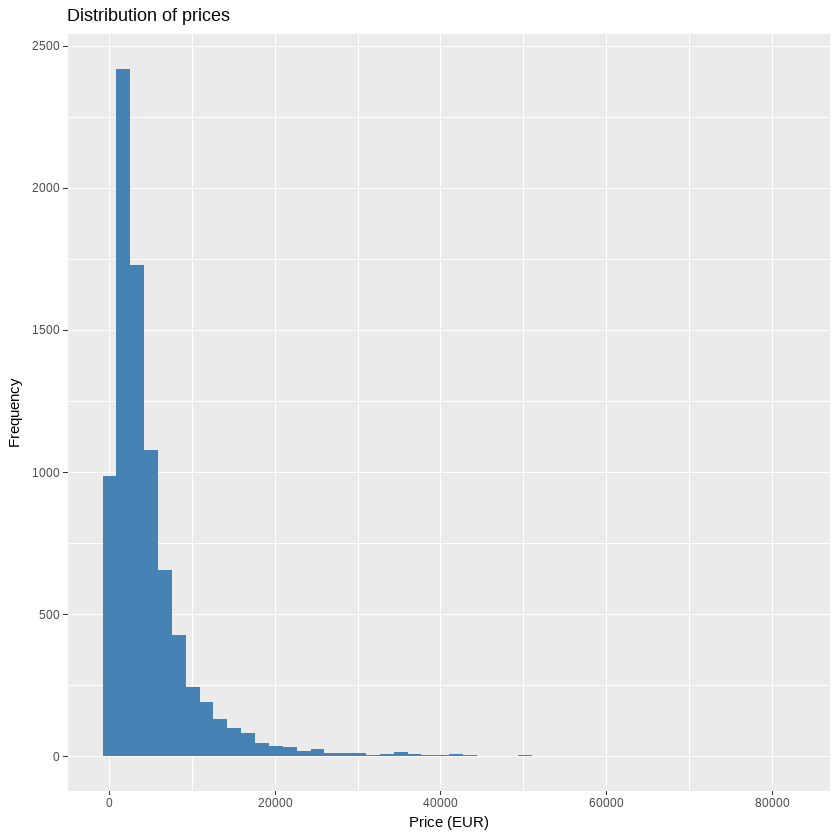

In [54]:
ggplot(cars, aes(x = price_eur)) +
  geom_histogram(fill = "steelblue", bins = 50) +
  labs(title = "Distribution of prices", x = "Price (EUR)", y = "Frequency")

`geom_smooth()` using formula = 'y ~ x'


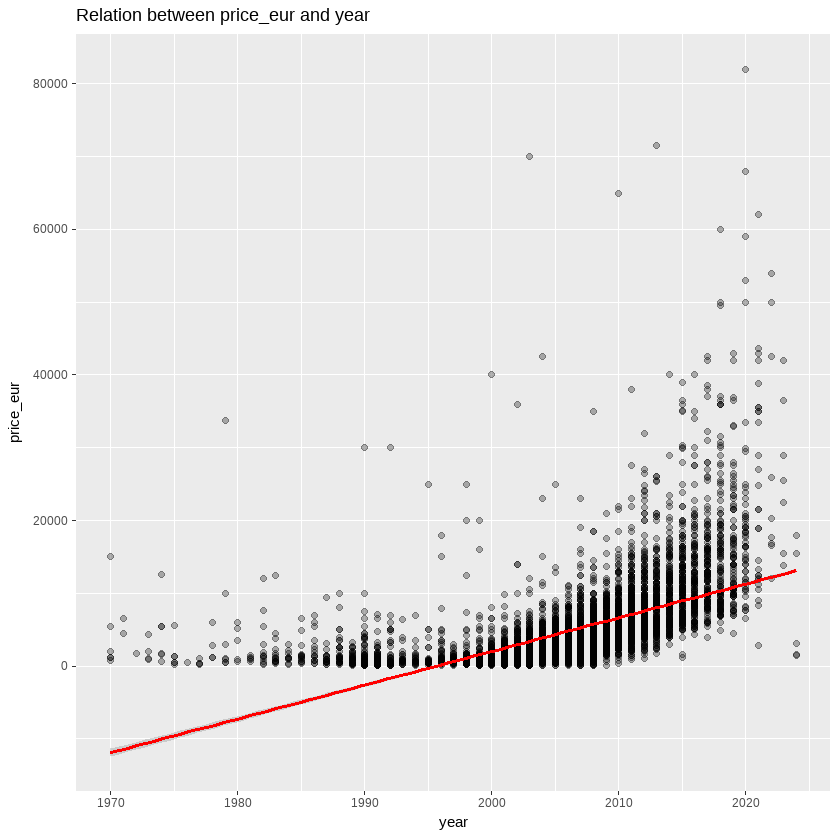

In [56]:
ggplot(cars, aes(x = year, y = price_eur)) +
  geom_point(alpha = 0.3, color = "black") +
  geom_smooth(method = "lm", color = "red") +
  labs(title = "Relation between price_eur and year")

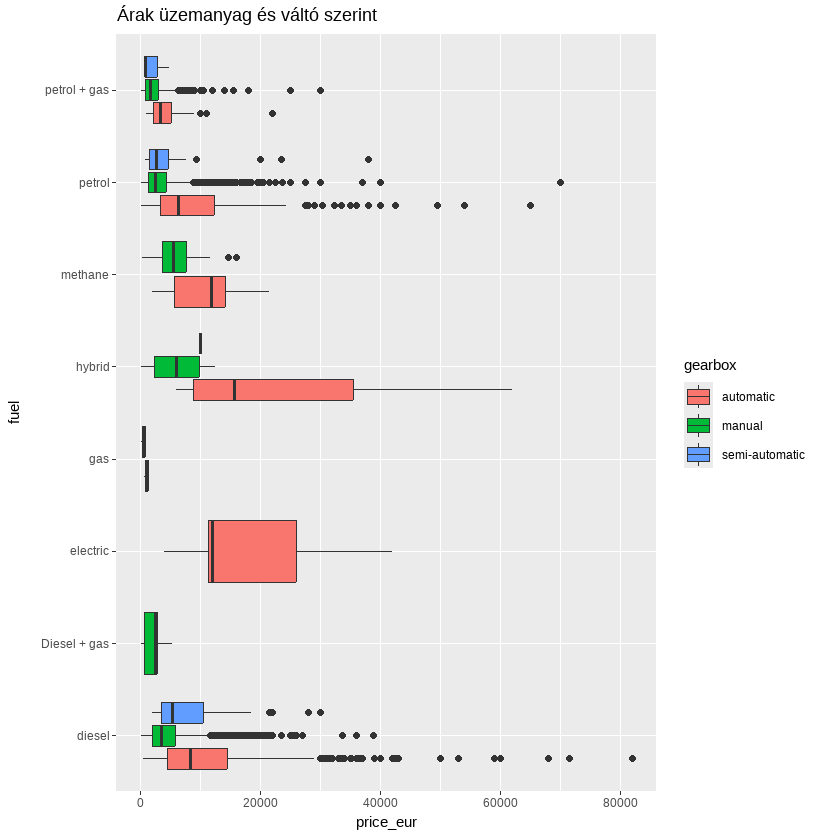

In [53]:
ggplot(cars, aes(x = fuel, y = price_eur, fill = gearbox)) +
  geom_boxplot() +
  coord_flip() + 
  labs(title = "Prices grouped by gearbox and fuel")

Installing package into 'C:/Users/balint.mark.schmidt/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'corrplot' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\balint.mark.schmidt\AppData\Local\Temp\RtmpIt0ooO\downloaded_packages


corrplot 0.95 loaded



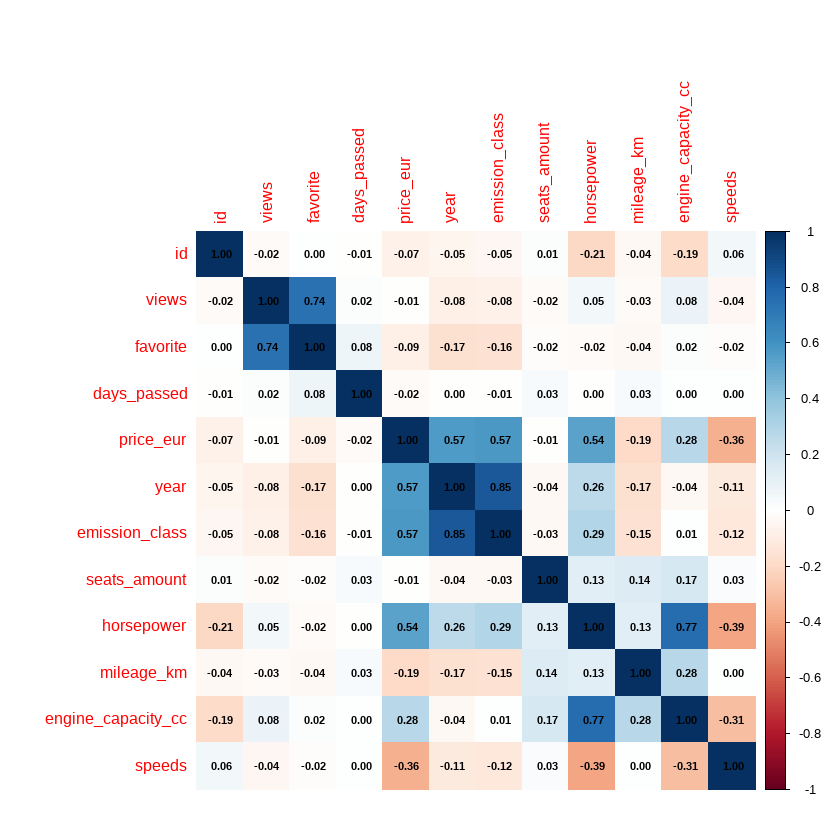

In [58]:
#install.packages("corrplot")
library(corrplot)
num_vars <- cars %>% select(where(is.numeric))
M <- cor(num_vars, use = "complete.obs")
corrplot(M, method = "color", addCoef.col = "black", number.cex = 0.7)

## Model